<a href="https://colab.research.google.com/github/anju-kris/AI-Driven-Loan-Approval-Risk-Analysis-Dashboard-Power-BI-SQL-Python/blob/main/LOAN_RISK_%26_APPROVAL_ANALYSIS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset (assuming it's uploaded to your Colab files)
df = pd.read_csv('loan_risk_prediction_dataset.csv')

# 1. Initial Check
print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None

--- Missing Values ---
Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved        

Removed 0 duplicate rows.


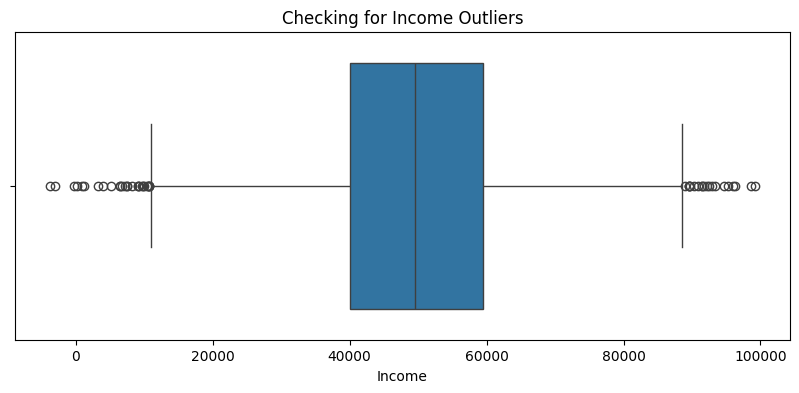

In [ ]:
# 2. Handle Missing Values
# We use 'median' for Income because it's less affected by extreme outliers than the 'average'
if df['Income'].isnull().sum() > 0:
    df['Income'] = df['Income'].fillna(df['Income'].median())

# 3. Remove Duplicates
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Removed {duplicate_count} duplicate rows.")

# 4. Outlier Check (Quick Visual)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Income'])
plt.title('Checking for Income Outliers')
plt.show()


In [ ]:
import numpy as np

# Step 1: Replace all negative values with NaN (Not a Number)
df.loc[df['Income'] < 0, 'Income'] = np.nan
df.loc[df['LoanAmount'] < 0, 'LoanAmount'] = np.nan

# Step 2: Fill those NaNs using the median
df['Income'] = df['Income'].fillna(df['Income'].median())
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Step 3: Verify there are no negatives or nulls left
print(f"Negative Incomes: {(df['Income'] < 0).sum()}")
print(f"Negative Loan Amounts: {(df['LoanAmount'] < 0).sum()}")
print(f"Missing Values: {df.isnull().sum().sum()}")


Negative Incomes: 0
Negative Loan Amounts: 0
Missing Values: 392


In [ ]:
df[['Income', 'LoanAmount']].describe()


,Income,LoanAmount
count,5000.000000,5000.000000
mean,49759.416400,19998.109000
std,14747.292014,7861.795956
min,129.000000,4.000000
25%,40036.000000,14599.750000
50%,49488.000000,19881.000000
75%,59447.000000,25326.750000
max,99146.000000,48353.000000


In [ ]:
# Blanks in CreditScore
print(f"Blanks in CreditScore: {df['CreditScore'].isnull().sum()}")


Blanks in CreditScore: 194


In [ ]:
# 1. Fill the 194 blanks with the median Credit Score
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())

# 2. Double-check that blanks are now 0
print(f"Remaining blanks in CreditScore: {df['CreditScore'].isnull().sum()}")


Remaining blanks in CreditScore: 0


In [ ]:
# Blanks in Education
print(f"Blanks in Education: {df['Education'].isnull().sum()}")


Blanks in Education: 198


In [ ]:
# 1. Fill blanks in the Education column with 'Unknown'
df['Education'] = df['Education'].fillna('Unknown')

# 2. Capitalize all entries to keep them consistent (e.g., 'graduate' vs 'Graduate')
df['Education'] = df['Education'].str.title()

# 3. Verify the change
print(df['Education'].value_counts())


Education
Bachelors      1220
Phd            1199
Masters        1198
High School    1185
Unknown         198
Name: count, dtype: int64


In [ ]:
# Save the cleaned dataframe to a CSV file
df.to_csv('cleaned_loan_risk_data.csv', index=False)

# If using Google Colab, this will prompt a download to your computer
from google.colab import files
files.download('cleaned_loan_risk_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>